In [1]:
import uproot
import matplotlib.pyplot as plt
import ROOT
from IPython.display import Image, display
import numpy as np
import mplhep as hep
import awkward as ak
hep.style.use("CMS")
import time

Welcome to JupyROOT 6.30/03


In [11]:
processDict = {"TTbar": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v9Reco/250221_140024/TTto4Q.root",
                        "/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v9Reco/250221_140030/TTtoLNu2Q.root"],
               "QCD": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v9Reco/250221_140103/QCD-4Jets_Bin-HT-200to400.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v9Reco/250221_140111/QCD-4Jets_Bin-HT-400to600.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v9Reco/250221_140118/QCD-4Jets_Bin-HT-600to800.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v9Reco/250221_140125/QCD-4Jets_Bin-HT-800to1000.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v9Reco/250221_140036/QCD-4Jets_Bin-HT-1000to1200.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v9Reco/250221_140043/QCD-4Jets_Bin-HT-1200to1500.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v9Reco/250221_140049/QCD-4Jets_Bin-HT-1500to2000.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v9isScouting/250223_101433/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v9Reco/250221_135939/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
             "Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v9Reco/250221_135923/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v9Reco/250221_135956/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v9Reco/250221_140012/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v9Reco/250221_135928/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v9Reco/250221_135945/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v9Reco/250221_140001/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v9Reco/250221_140018/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v9Reco/250221_135917/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v9Reco/250221_135933/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v9Reco/250221_135950/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v9Reco/250221_140006/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

In [2]:
processDict = {"TTbar": ["/eos/cms/store/group/phys_exotica/DVScouting/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/TTto4Q_Tree_v9isScouting/250223_101355/TTto4Q.root",
                        "/eos/cms/store/group/phys_exotica/DVScouting/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/TTtoLNu2Q_Tree_v9isScouting/250223_101400/TTtoLNu2Q.root"],
               "QCD": ["/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-200to400_Tree_v9isScouting/250223_101442/QCD-4Jets_Bin-HT-200to400.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-400to600_Tree_v9isScouting/250223_101449/QCD-4Jets_Bin-HT-400to600.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-600to800_Tree_v9isScouting/250223_101458/QCD-4Jets_Bin-HT-600to800.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-800to1000_Tree_v9isScouting/250223_101505/QCD-4Jets_Bin-HT-800to1000.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v9isScouting/250223_101407/QCD-4Jets_Bin-HT-1000to1200.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1200to1500_Tree_v9isScouting/250223_101416/QCD-4Jets_Bin-HT-1200to1500.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1500to2000_Tree_v9isScouting/250223_101425/QCD-4Jets_Bin-HT-1500to2000.root",
                       "/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-2000_Tree_v9isScouting/250223_101433/QCD-4Jets_Bin-HT-2000.root"]}
signalDict = {"Stop-M400-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-1mm_Tree_v9isScouting/250223_101306/StopStopbarTo2Dbar2D_M-400_CTau-1mm.root"],
             "Stop-M200-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-1mm_Tree_v9isScouting/250223_101248/StopStopbarTo2Dbar2D_M-200_CTau-1mm.root"],
              "Stop-M600-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-1mm_Tree_v9isScouting/250223_101322/StopStopbarTo2Dbar2D_M-600_CTau-1mm.root"],
              "Stop-M800-cT1": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-1mm_Tree_v9isScouting/250223_101340/StopStopbarTo2Dbar2D_M-800_CTau-1mm.root"],
              "Stop-M200-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-3mm_Tree_v9isScouting/250223_101254/StopStopbarTo2Dbar2D_M-200_CTau-3mm.root"],
              "Stop-M400-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-3mm_Tree_v9isScouting/250223_101312/StopStopbarTo2Dbar2D_M-400_CTau-3mm.root"],
              "Stop-M600-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-3mm_Tree_v9isScouting/250223_101328/StopStopbarTo2Dbar2D_M-600_CTau-3mm.root"],
              "Stop-M800-cT3": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-3mm_Tree_v9isScouting/250223_101348/StopStopbarTo2Dbar2D_M-800_CTau-3mm.root"],
              "Stop-M200-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-200_CTau-10mm_Tree_v9isScouting/250223_101242/StopStopbarTo2Dbar2D_M-200_CTau-10mm.root"],
              "Stop-M400-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-400_CTau-10mm_Tree_v9isScouting/250223_101300/StopStopbarTo2Dbar2D_M-400_CTau-10mm.root"],
              "Stop-M600-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-600_CTau-10mm_Tree_v9isScouting/250223_101317/StopStopbarTo2Dbar2D_M-600_CTau-10mm.root"],
              "Stop-M800-cT10": ["/eos/cms/store/group/phys_exotica/DVScouting/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Summer24_100k_v2/StopStopbarTo2Dbar2D_M-800_CTau-10mm_Tree_v9isScouting/250223_101334/StopStopbarTo2Dbar2D_M-800_CTau-10mm.root"]
             }

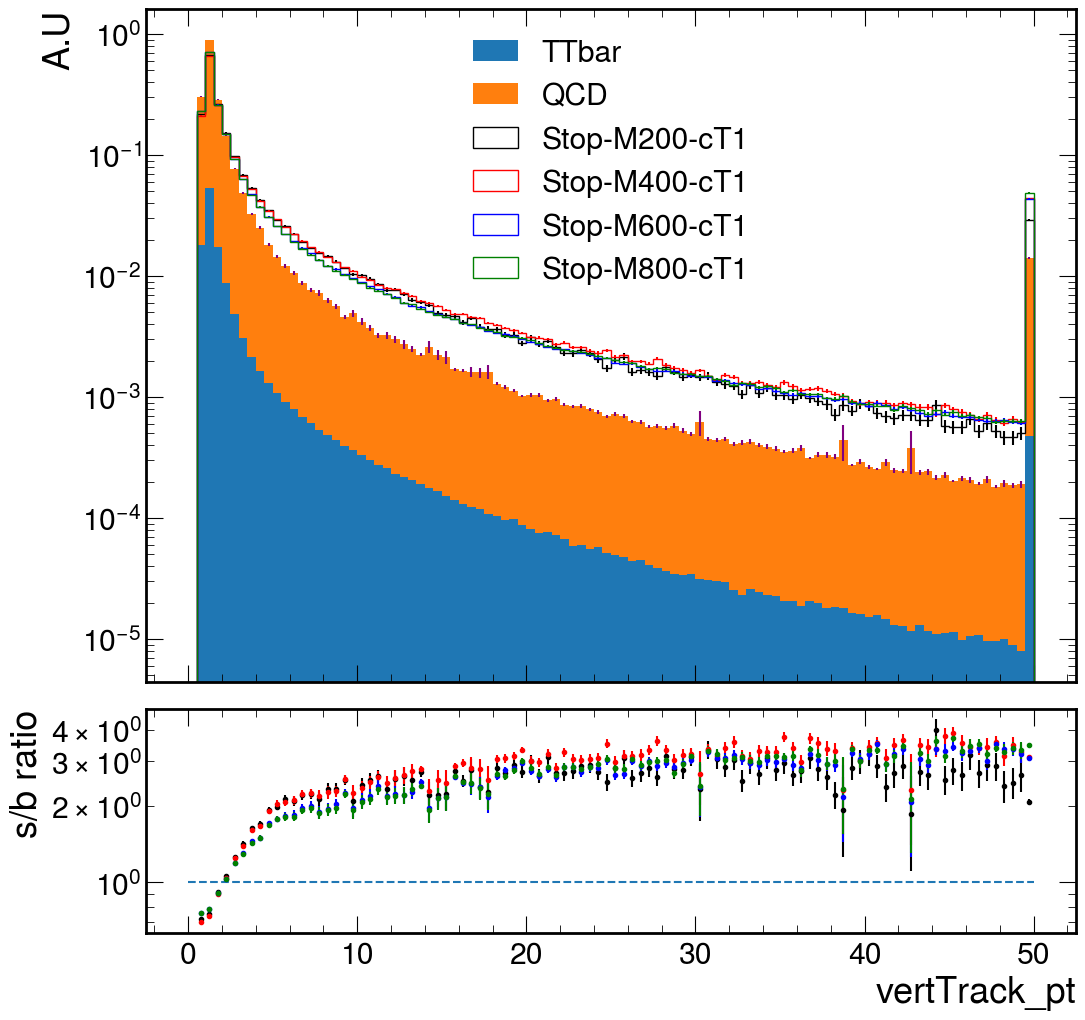

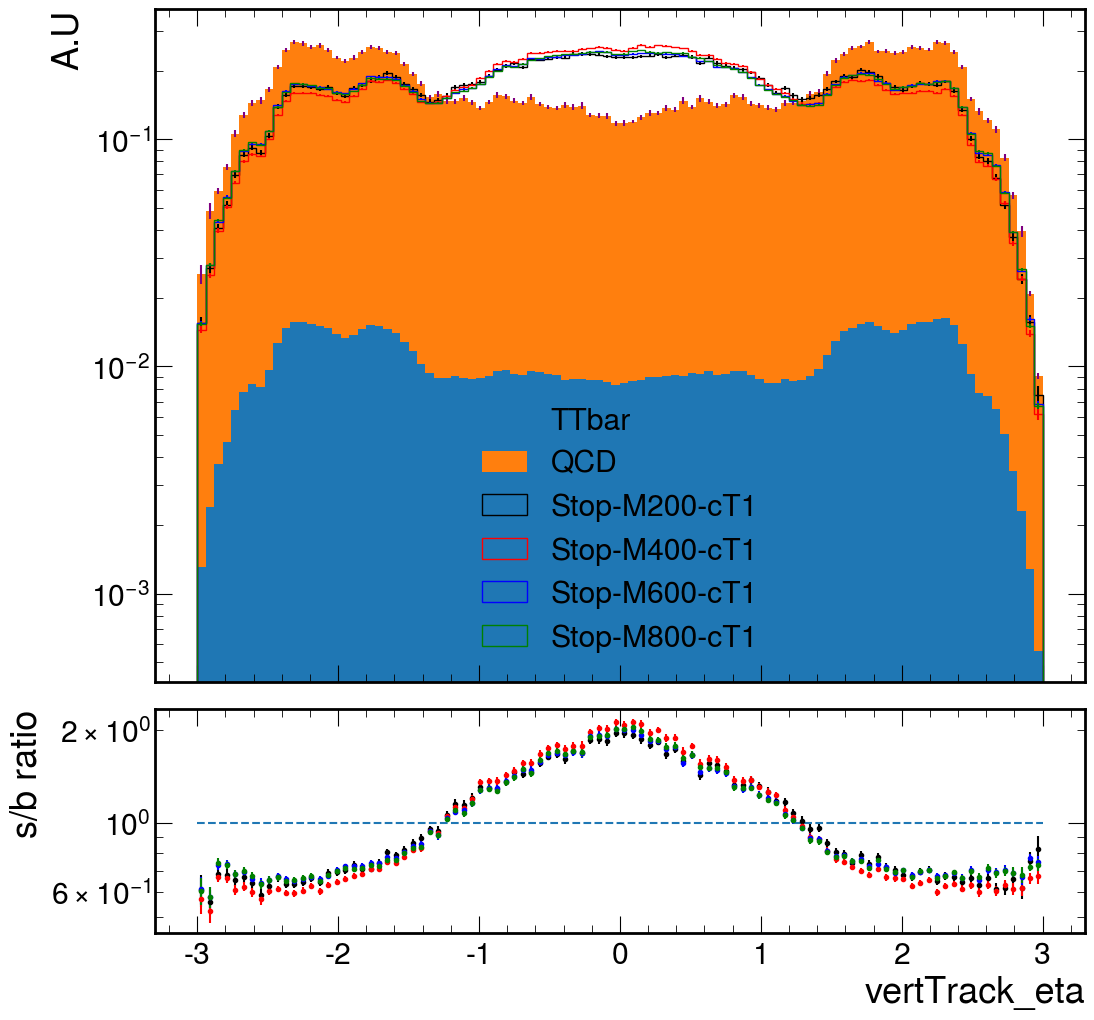

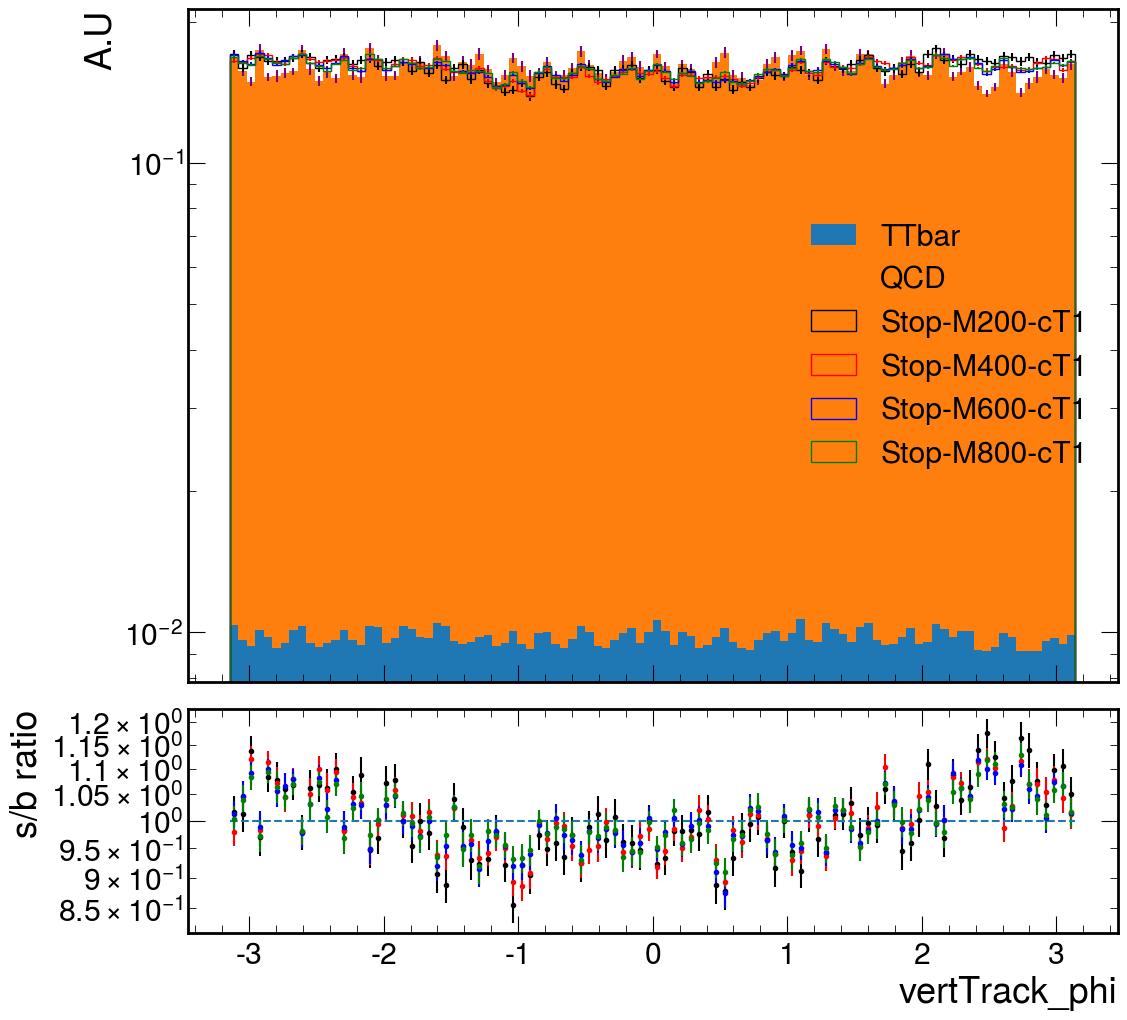

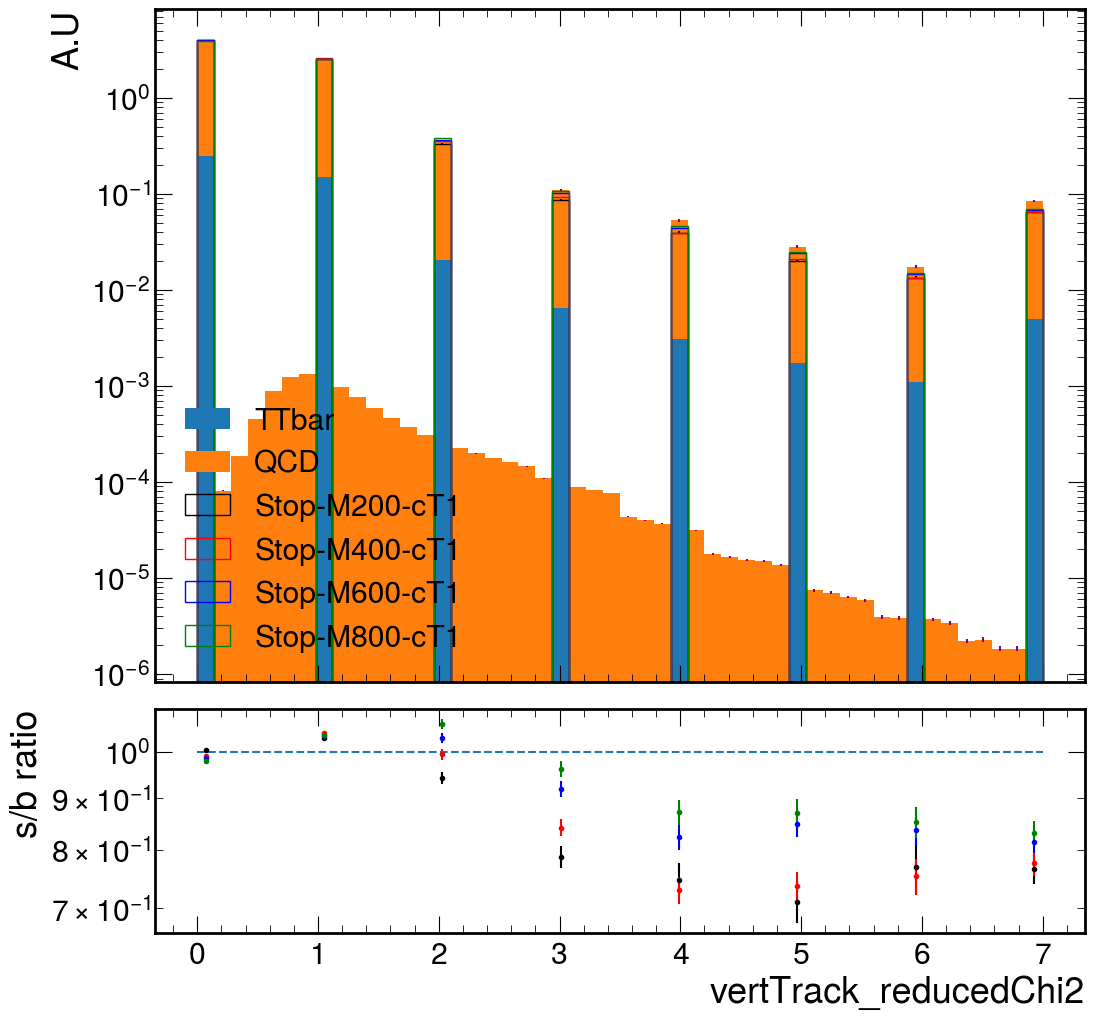

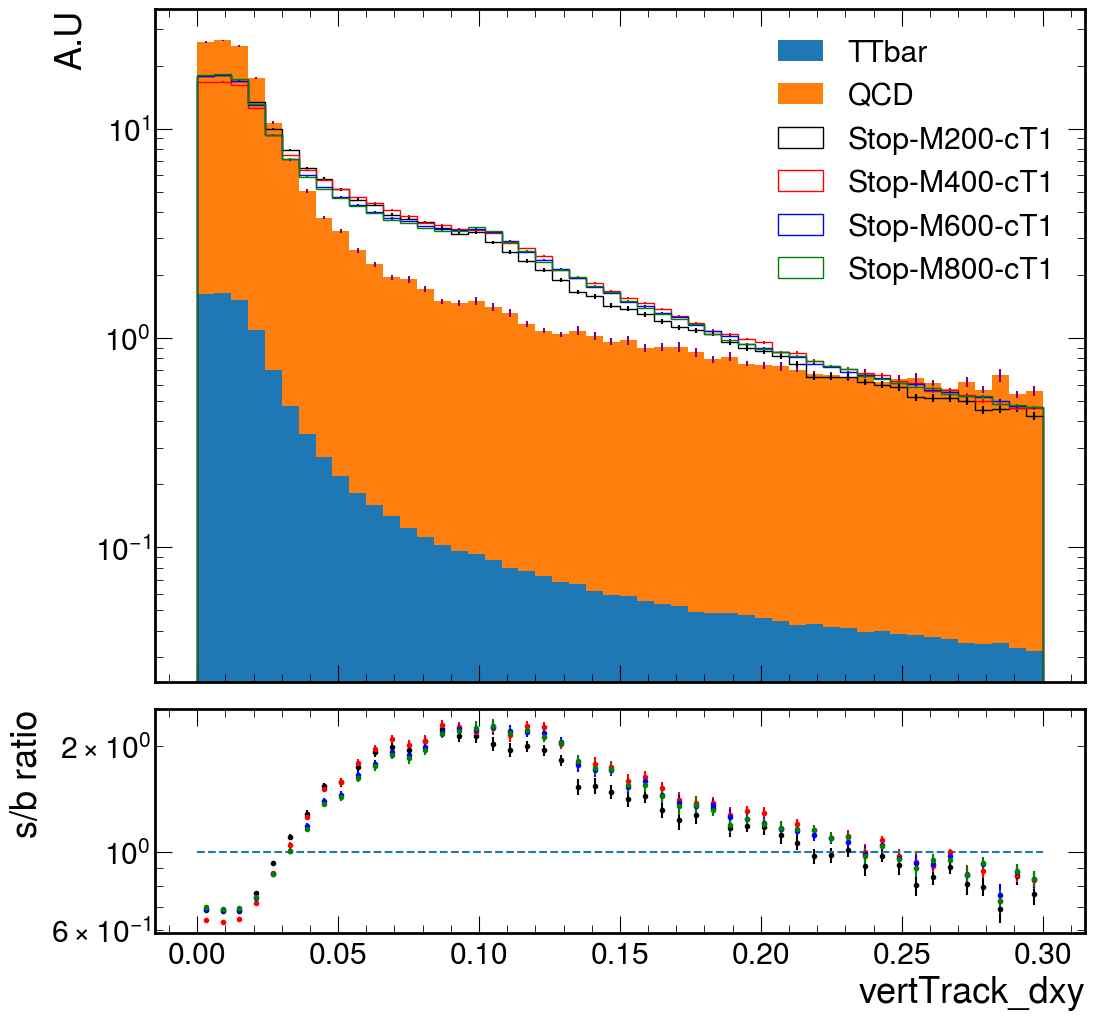

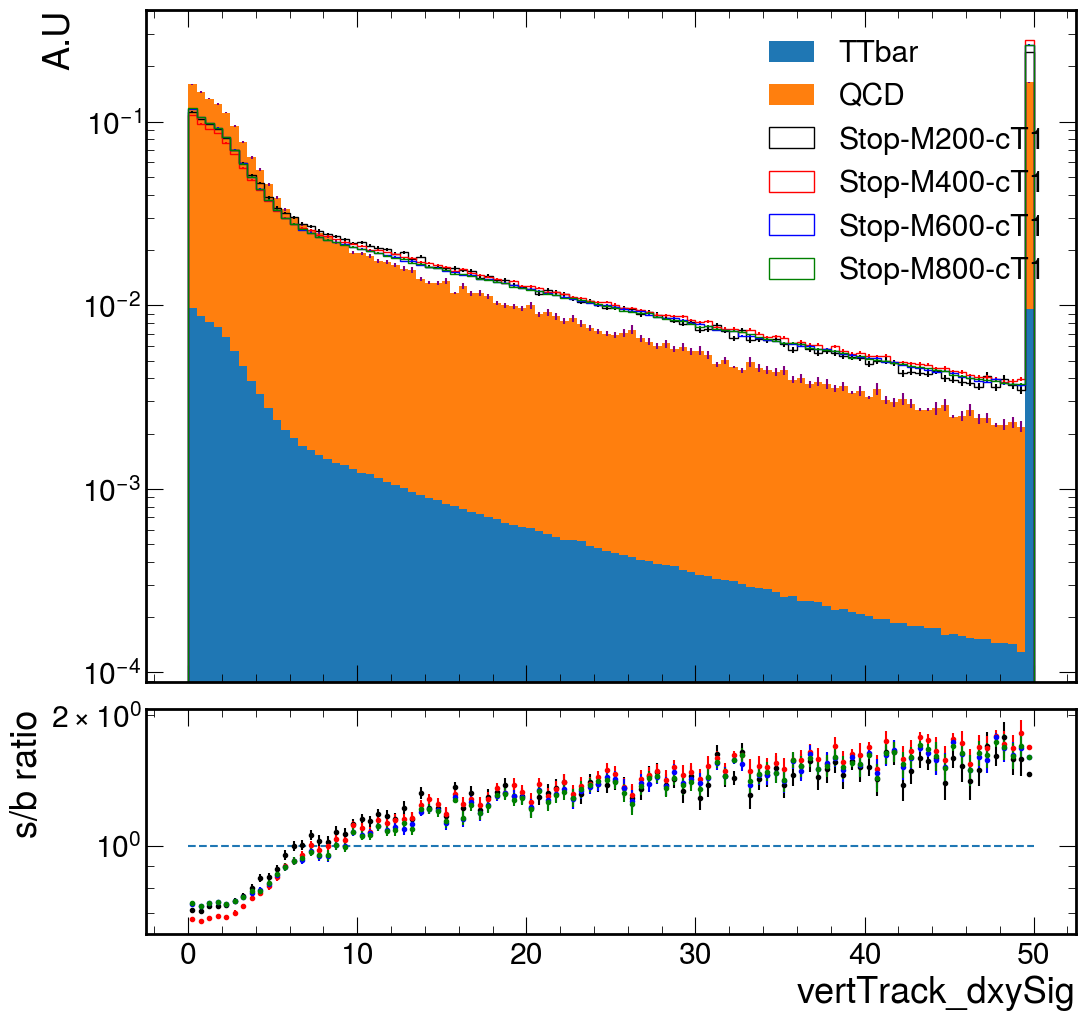

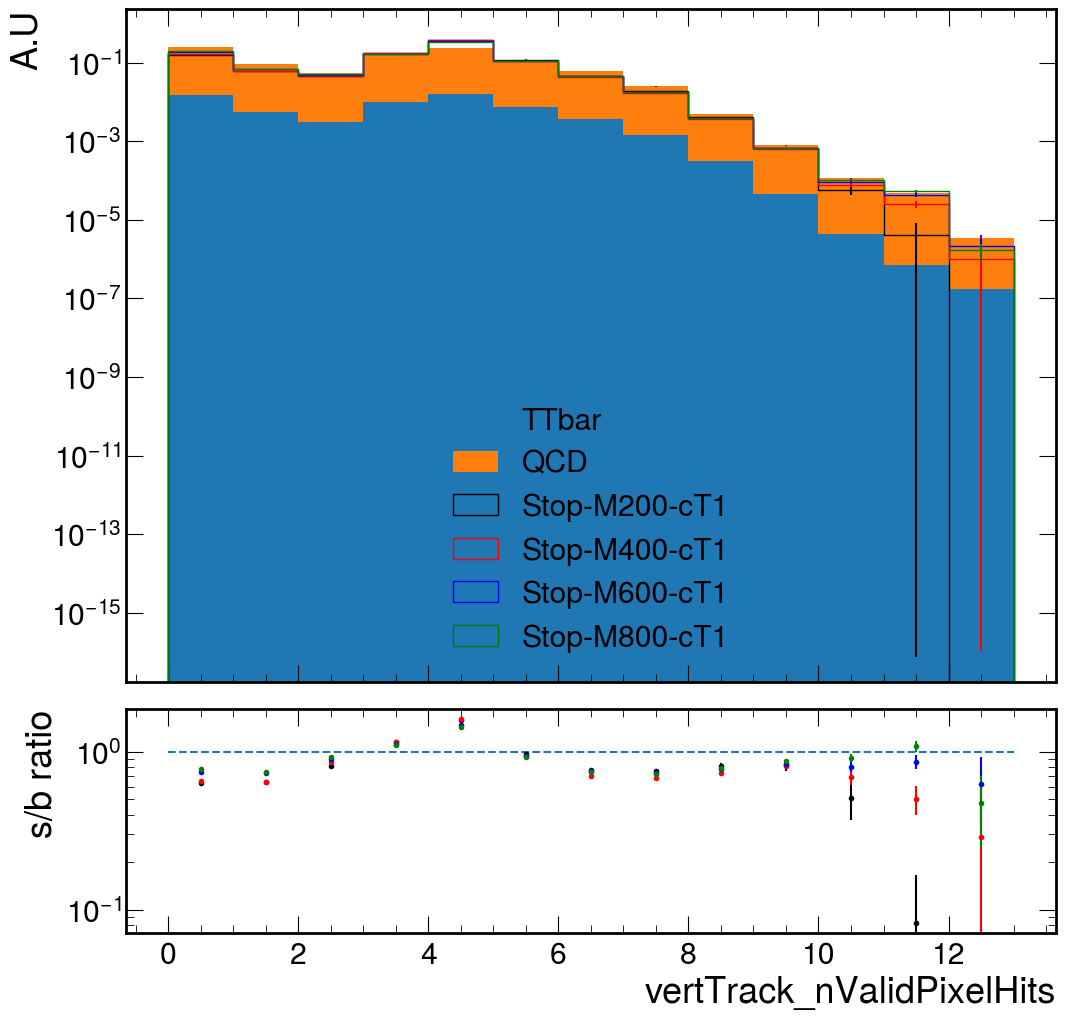

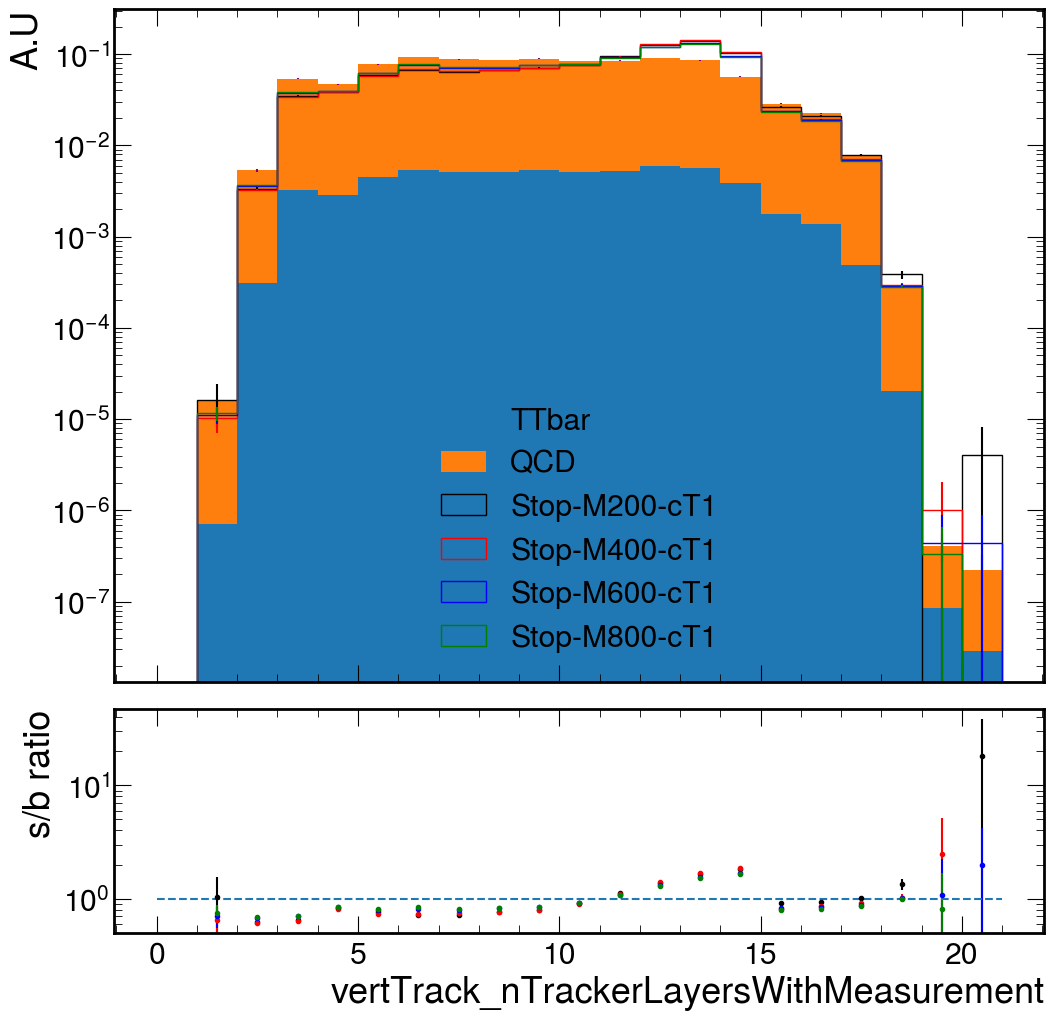

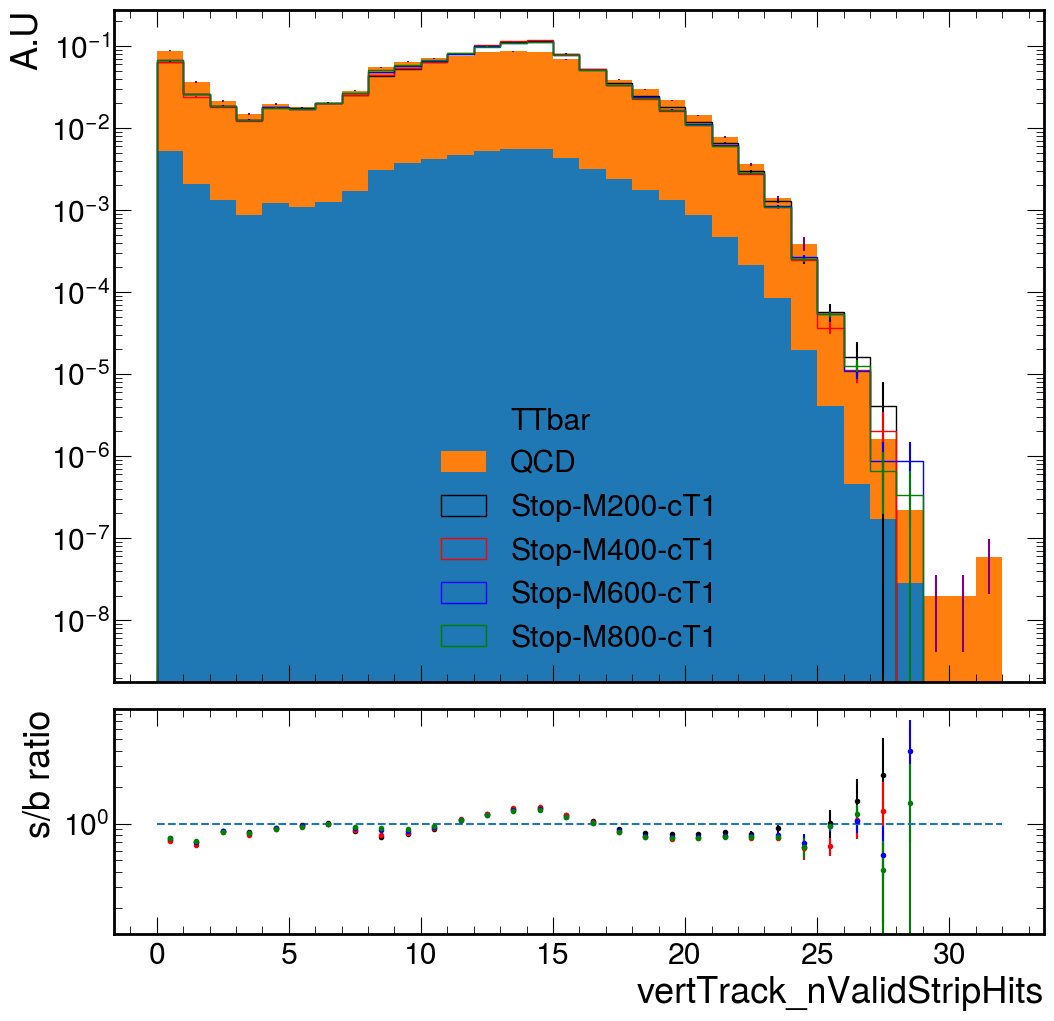

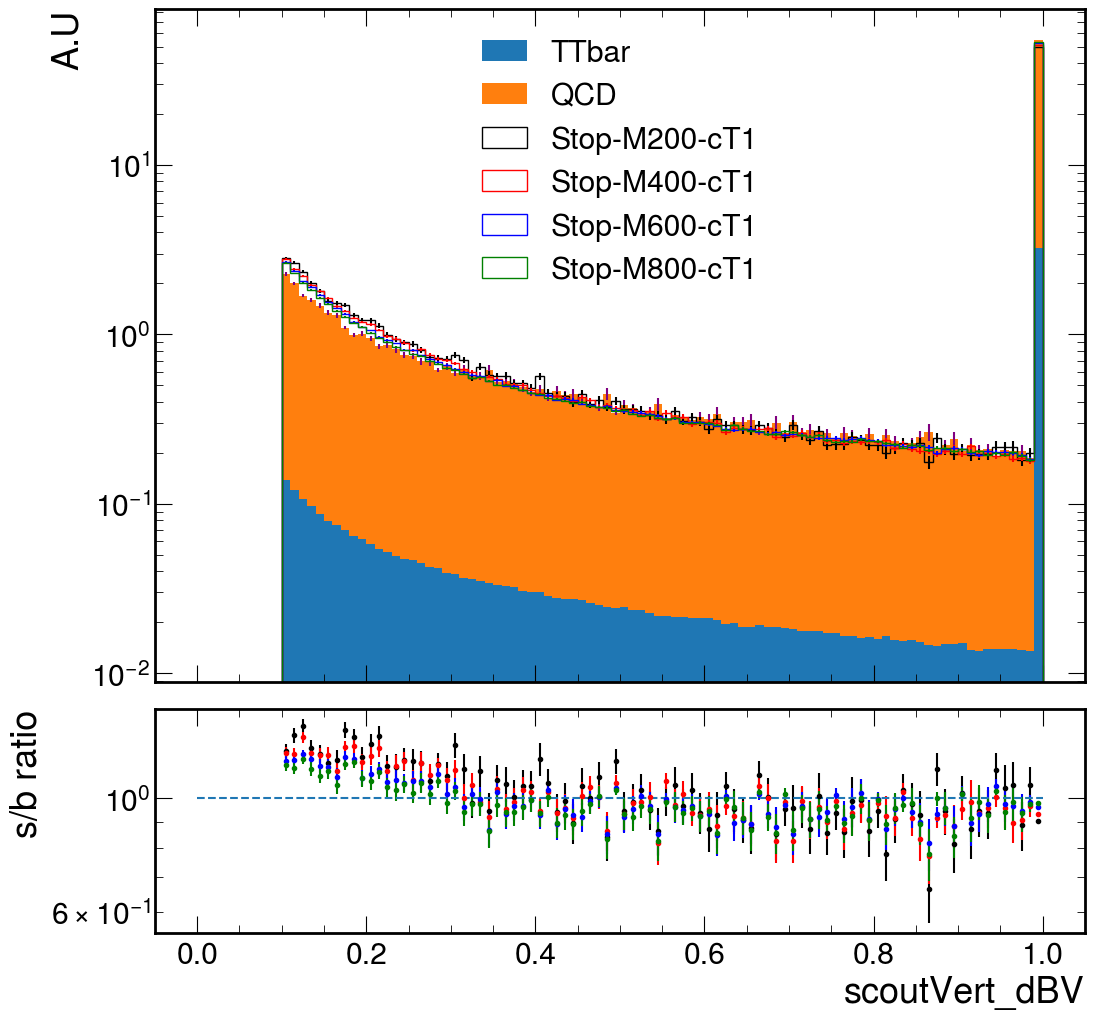

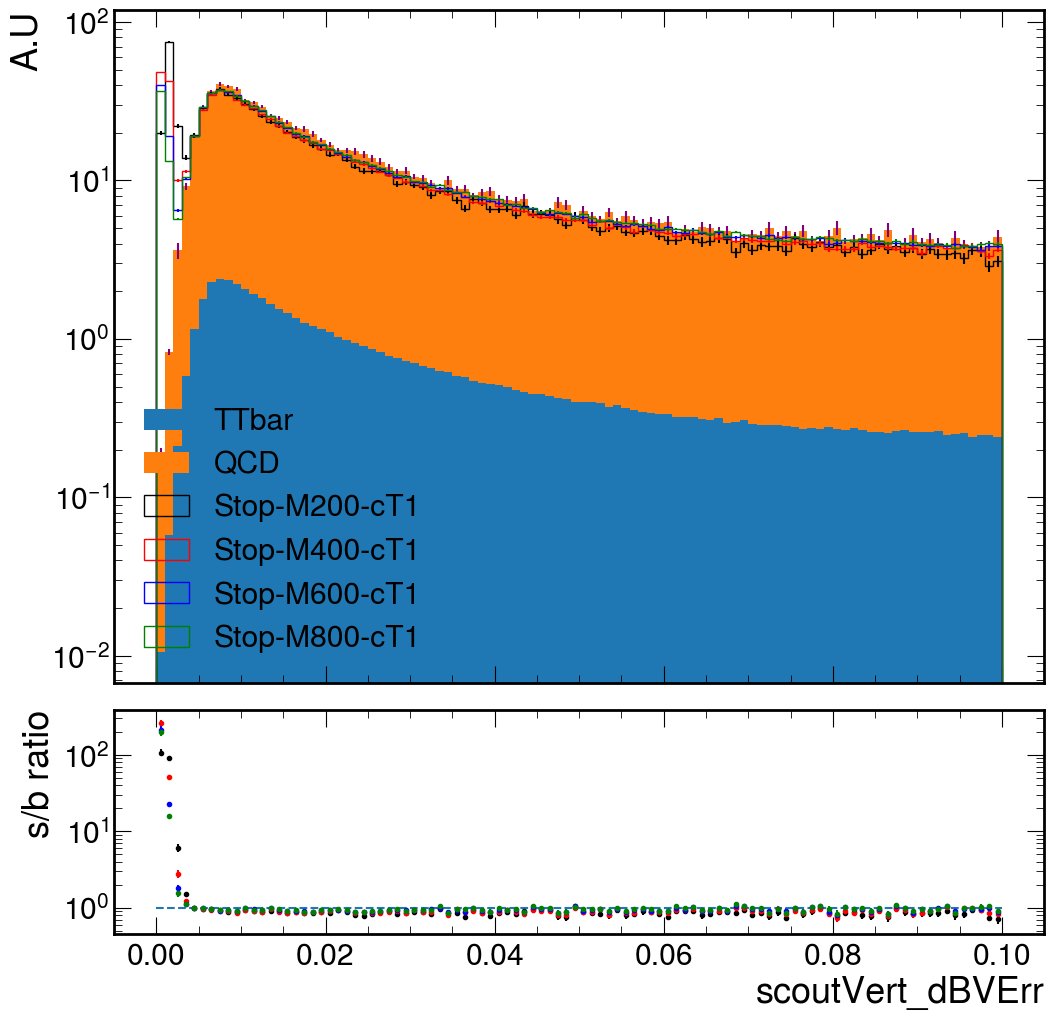

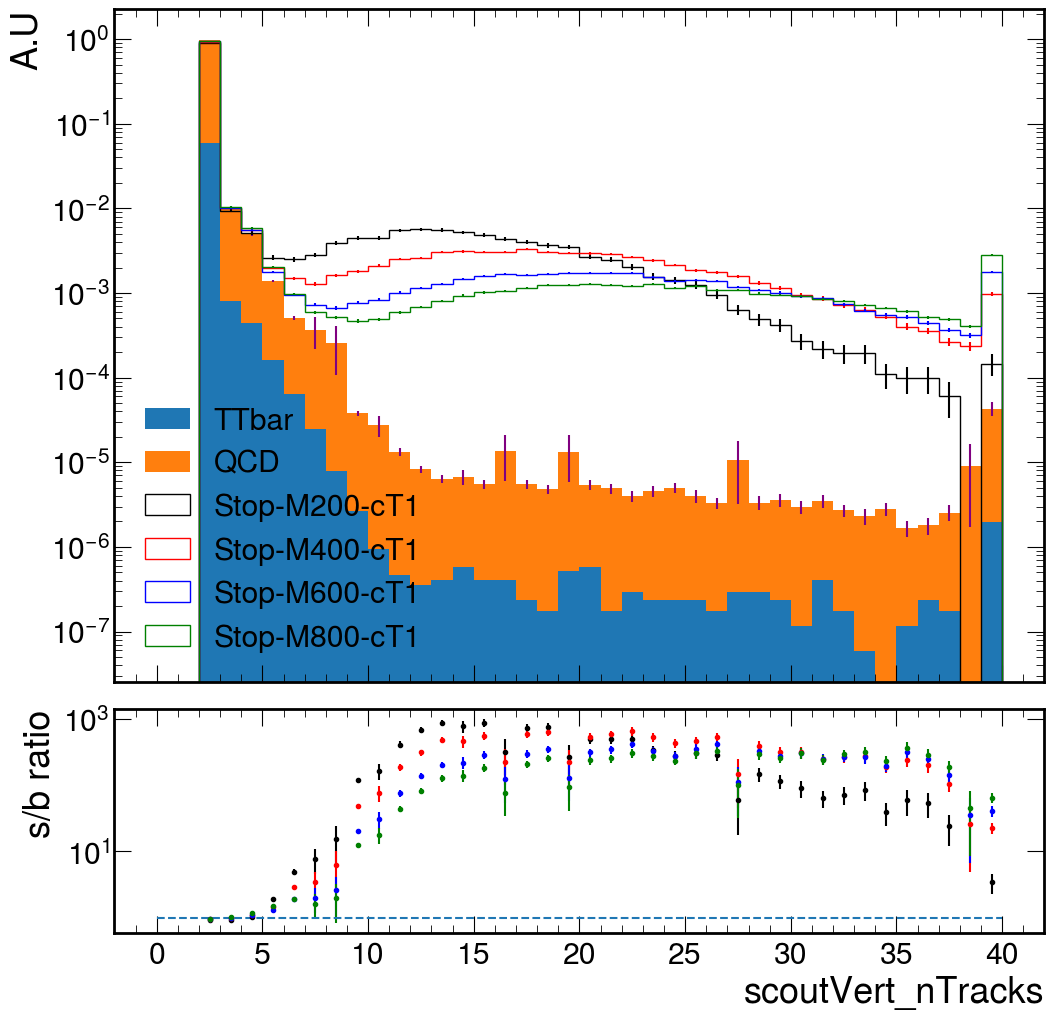

3307.4892094135284


In [41]:
plotDict = {"vertTrack_pt": [0,50,101], "vertTrack_eta": [-3,3,101], "vertTrack_phi": [-3.142,3.142,101], 
            "vertTrack_reducedChi2": [0,7,51], "vertTrack_dxy": [0,0.3,51], "vertTrack_dxySig": [0,50,101], #"vertTrack_d3D": [0,15,101], 
            #"vertTrack_d3DSig": [0,1250,301], "vertTrack_dz": [-20,20,101], "vertTrack_dzSig": [-2000,2000,501], 
            "vertTrack_nValidPixelHits": [0,13,14], 
            "vertTrack_nTrackerLayersWithMeasurement": [0,21,22], "vertTrack_nValidStripHits": [0,32,33], #"scoutTrack_minPVDxy": [0,0.1,100], "scoutTrack_minPVDz": [-0.3,0.3,100],
            "scoutVert_dBV": [0,1,101], "scoutVert_dBVErr": [0,0.1,101], "scoutVert_nTracks": [0,40,41]
            }

#plotDict = {"scoutVert_nVertices" : [0,30,30]}
'''
t0 = time.time()   
bgPlotData = {}
bgPlotWeights = {}
bgPlotWeightsSquared = {}
for process, rootFiles in processDict.items():
    for rootFile in rootFiles:
        print(rootFile)
        genWeightSum = 0
        with uproot.open(rootFile+":triggerFilter") as file:
            genWeightSum = file["genWeightsSkim"].values()[0]
        with uproot.open(rootFile+":scoutingTree") as file:
            tree = file["objectTree"]
            array = tree.arrays(list(plotDict.keys())+["vertTrack_iVtx"],library="ak")
            weights = file["tree/weight"].array(library="ak")
            weights = weights / genWeightSum
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0],binning[1],binning[2])
                processData = (bins[:-1] + bins[1:]) / 2
                data = array[plot]
                if("vertTrack" in plot):
                    dispArray = array["scoutVert_dBV"][array["vertTrack_iVtx"]]
                    data = data[dispArray>=0.1]
                elif("scoutVert" in plot):
                    dispArray = array["scoutVert_dBV"]
                    data = data[dispArray>=0.1]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                if(data.layout.minmax_depth[1]>1): data = ak.flatten(data)
                data = np.clip(data,bins[0],bins[-1])
                if(broadcastWeights.layout.minmax_depth[1]>1): broadcastWeights = ak.flatten(broadcastWeights)
                n, bin_edges = np.histogram(data,weights=broadcastWeights,bins=bins)
                n_2, bin_edges = np.histogram(data,weights=broadcastWeights**2,bins=bins)
                if plot not in bgPlotWeights:
                    bgPlotWeights[plot] = {process: n}
                    bgPlotWeightsSquared[plot] = {process: n_2}
                    bgPlotData[plot] = {process: processData}
                elif process in bgPlotWeights[plot]:
                    bgPlotWeights[plot][process] = bgPlotWeights[plot][process] + n
                    bgPlotWeightsSquared[plot][process] = bgPlotWeightsSquared[plot][process] + n_2
                else:
                    bgPlotWeights[plot][process] = n
                    bgPlotWeightsSquared[plot][process] = n_2
                    bgPlotData[plot][process] = processData


sigPlotData = {}
sigPlotWeights = {}
sigPlotWeightsSquared = {}
for process, rootFiles in signalDict.items():
    for rootFile in rootFiles:
        print(rootFile)
        genWeightSum = 0
        with uproot.open(rootFile+":triggerFilter") as file:
            genWeightSum = file["genWeightsSkim"].values()[0]
        with uproot.open(rootFile+":scoutingTree") as file:
            tree = file["objectTree"]
            array = tree.arrays(list(plotDict.keys())+["vertTrack_iVtx"],library="ak")
            weights = file["tree/weight"].array(library="ak")
            weights = weights / genWeightSum
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0],binning[1],binning[2])
                processData = (bins[:-1] + bins[1:]) / 2
                data = array[plot]
                if("vertTrack" in plot):
                    dispArray = array["scoutVert_dBV"][array["vertTrack_iVtx"]]
                    data = data[dispArray>=0.1]
                elif("scoutVert" in plot):
                    dispArray = array["scoutVert_dBV"]
                    data = data[dispArray>=0.1]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                if(data.layout.minmax_depth[1]>1): data = ak.flatten(data)
                data = np.clip(data,bins[0],bins[-1])
                if(broadcastWeights.layout.minmax_depth[1]>1): broadcastWeights = ak.flatten(broadcastWeights)
                n, bin_edges = np.histogram(data,weights=broadcastWeights,bins=bins)
                n_2, bin_edges = np.histogram(data,weights=broadcastWeights**2,bins=bins)
                if plot not in sigPlotWeights:
                    sigPlotWeights[plot] = {process: n}
                    sigPlotWeightsSquared[plot] = {process: n_2}
                    sigPlotData[plot] = {process: processData}
                elif process in sigPlotWeights[plot]:
                    sigPlotWeights[plot][process] = sigPlotWeights[plot][process] + n
                    sigPlotWeightsSquared[plot][process] = sigPlotWeightsSquared[plot][process] + n_2
                else:
                    sigPlotWeights[plot][process] = n
                    sigPlotWeightsSquared[plot][process] = n_2
                    sigPlotData[plot][process] = processData
'''
for plot, binning in plotDict.items():
    bins = np.linspace(binning[0],binning[1],binning[2])
    bgIntegral = (bins[1]-bins[0])*ak.sum(bgPlotWeights[plot]["QCD"]+bgPlotWeights[plot]["TTbar"])
    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist(list(bgPlotData[plot].values()),weights=list(bgPlotWeights[plot].values()),stacked=True,density=True,label=list(bgPlotWeights[plot].keys()),bins=bins)
    bgValues = (bgPlotWeights[plot]["QCD"]/bgIntegral)+(bgPlotWeights[plot]["TTbar"]/bgIntegral)
    bgErrors = np.sqrt(bgPlotWeightsSquared[plot]["QCD"]/(bgIntegral**2))+np.sqrt(bgPlotWeightsSquared[plot]["TTbar"]/(bgIntegral**2))
    ax.errorbar(((bins[:-1] + bins[1:]) / 2),list(bgValues),yerr=list(bgErrors),linestyle="none",color="purple")
    for string,color in {"Stop-M200-cT1": "black", "Stop-M400-cT1": "red", "Stop-M600-cT1": "blue", "Stop-M800-cT1": "green"}.items():
        integral = (bins[1]-bins[0])*ak.sum(sigPlotWeights[plot][string])
        ax.hist(list(sigPlotData[plot][string]),weights=list(sigPlotWeights[plot][string]),stacked=False,density=True,label=string,bins=bins,histtype="step",color=color)
        sigValues = sigPlotWeights[plot][string]/integral
        sigErrors = np.sqrt(sigPlotWeightsSquared[plot][string]/(integral**2))
        ax.errorbar(((bins[:-1] + bins[1:]) / 2),list(sigValues),yerr=list(sigErrors),linestyle="none",color=color)
        ratioValues = sigValues/bgValues
        ratioErrors = ratioValues*np.sqrt((sigErrors/sigValues)**2+(bgErrors/bgValues)**2)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2),list(ratioValues),yerr=list(ratioErrors),linestyle="none",color=color,marker=".")
    rax.hlines(1,bins[0],bins[-1],linestyle="dashed")
    rax.set_ylabel("s/b ratio")
    ax.set_ylabel(f"A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    rax.set_yscale("log")
    plt.show()
    
t1 = time.time()
total = t1-t0
print(total)

In [3]:
np.linspace(0,40,41)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40.])

In [8]:
for process, rootFiles in processDict.items():
    weightSum = 0
    displacedWeightSum = 0
    totalWeightSum = 0
    for rootFile in rootFiles:
        genWeightSum = 0
        with uproot.open(rootFile+":triggerFilter") as file:
            genWeightSum = file["genWeightsSkim"].values()[0]
            totalWeights = file["weightsSkim"].values()[0]
            totalWeightSum += totalWeights/genWeightSum
        with uproot.open(rootFile+":scoutingTree") as file:
            tree = file["objectTree"]
            array = tree.arrays(["scoutVert_dBV","scoutVert_dBVErr"],library="ak")
            weights = file["tree/weight"].array(library="ak")
            weights = weights / genWeightSum
            weightSum += ak.sum(weights)
            array1 = array["scoutVert_dBV"]
            array2 = array["scoutVert_dBVErr"]
            array1 = array1[array2<0.005]
            mask = ak.sum(array1>=0.1,axis=1)>0
            weights = weights[mask]
            displacedWeightSum += ak.sum(weights)
    print(process)
    print("Percentage of displaced events:",displacedWeightSum/weightSum)
    print("Percentage Cutflow dBV: ",weightSum/totalWeightSum,"Low Err dBV:",displacedWeightSum/totalWeightSum)

TTbar
Percentage of displaced events: 0.022648042383414346
Percentage Cutflow dBV:  0.3260416687810367 Low Err dBV: 0.007384205533312062
QCD
Percentage of displaced events: 0.032235972537120565
Percentage Cutflow dBV:  0.07451072691875364 Low Err dBV: 0.0024019257466738326


In [9]:
for process, rootFiles in signalDict.items():
    weightSum = 0
    displacedWeightSum = 0
    totalWeightSum = 0
    for rootFile in rootFiles:
        genWeightSum = 0
        with uproot.open(rootFile+":triggerFilter") as file:
            genWeightSum = file["genWeightsSkim"].values()[0]
            totalWeights = file["weightsSkim"].values()[0]
            totalWeightSum += totalWeights/genWeightSum
        with uproot.open(rootFile+":scoutingTree") as file:
            tree = file["objectTree"]
            array = tree.arrays(["scoutVert_dBV","scoutVert_dBVErr"],library="ak")
            weights = file["tree/weight"].array(library="ak")
            weights = weights / genWeightSum
            weightSum += ak.sum(weights)
            array1 = array["scoutVert_dBV"]
            array2 = array["scoutVert_dBVErr"]
            array1 = array1[array2<0.005]
            mask = ak.sum(array1>=0.1,axis=1)>0
            weights = weights[mask]
            displacedWeightSum += ak.sum(weights)
    print(process)
    print("Percentage of displaced events:",displacedWeightSum/weightSum)
    print("Percentage Cutflow dBV: ",weightSum/totalWeightSum,"Low Err dBV:",displacedWeightSum/totalWeightSum)

Stop-M400-cT1
Percentage of displaced events: 0.3742755465175275
Percentage Cutflow dBV:  0.5901000000001221 Low Err dBV: 0.22086000000003866
Stop-M200-cT1
Percentage of displaced events: 0.371524763377104
Percentage Cutflow dBV:  0.47704040404009657 Low Err dBV: 0.17723232323231497
Stop-M600-cT1
Percentage of displaced events: 0.37321486794912445
Percentage Cutflow dBV:  0.6134000000001274 Low Err dBV: 0.2289300000000405
Stop-M800-cT1
Percentage of displaced events: 0.3766176307930428
Percentage Cutflow dBV:  0.6328700000001318 Low Err dBV: 0.2383500000000426
Stop-M200-cT3
Percentage of displaced events: 0.367830910417114
Percentage Cutflow dBV:  0.589510000000122 Low Err dBV: 0.21684000000003775
Stop-M400-cT3
Percentage of displaced events: 0.44381512445635035
Percentage Cutflow dBV:  0.7394889779554987 Low Err dBV: 0.32819639278541896
Stop-M600-cT3
Percentage of displaced events: 0.48196101440771133
Percentage Cutflow dBV:  0.7669500000001621 Low Err dBV: 0.3696400000000723
Stop-M80

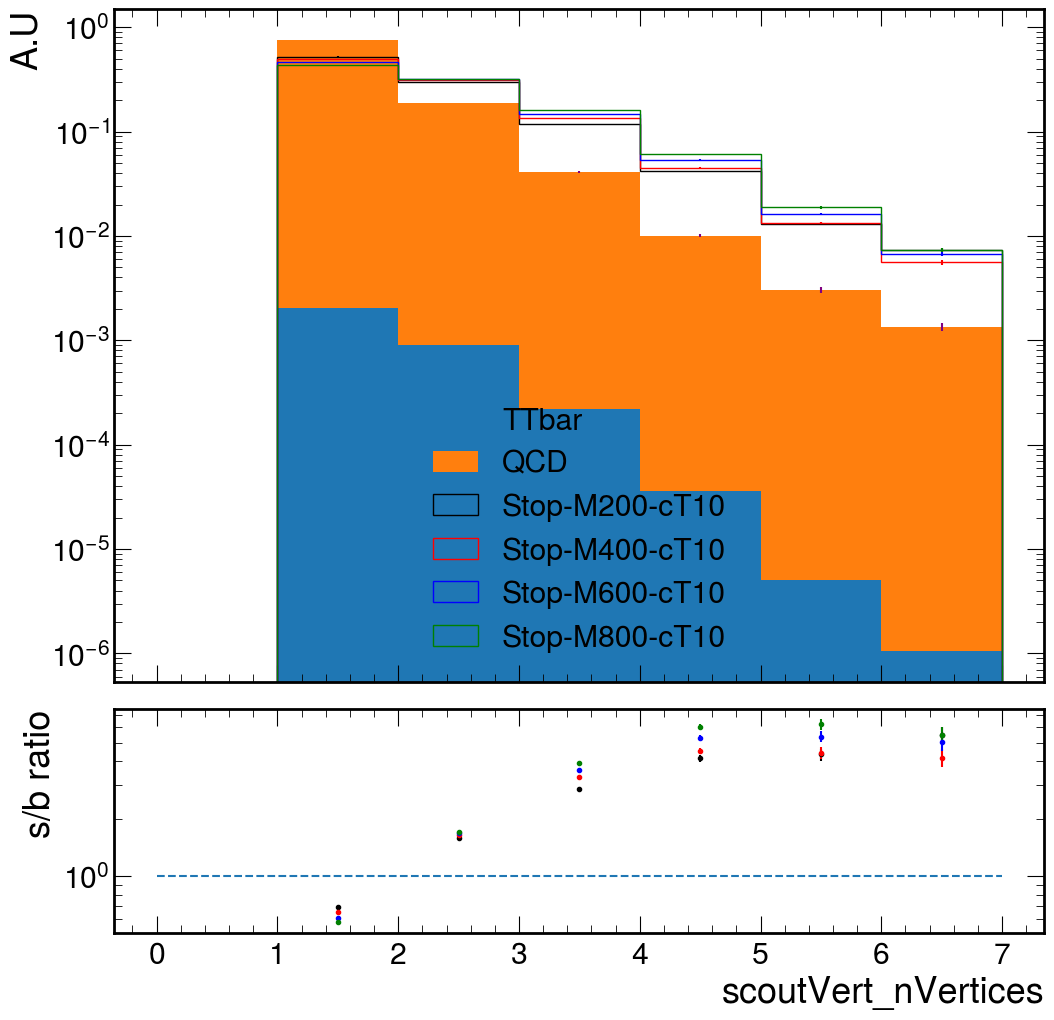

574.5230810642242


In [5]:
plotDict = {"scoutVert_dBV": [0,7,8]}
'''
t0 = time.time()   
bgPlotData = {}
bgPlotWeights = {}
bgPlotWeightsSquared = {}
for process, rootFiles in processDict.items():
    for rootFile in rootFiles:
        print(rootFile)
        genWeightSum = 0
        with uproot.open(rootFile+":triggerFilter") as file:
            genWeightSum = file["genWeightsSkim"].values()[0]
        with uproot.open(rootFile+":scoutingTree") as file:
            tree = file["objectTree"]
            array = tree.arrays(list(plotDict.keys()),library="ak")
            weights = file["tree/weight"].array(library="ak")
            weights = weights / genWeightSum
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0],binning[1],binning[2])
                processData = (bins[:-1] + bins[1:]) / 2
                data = array[plot]
                if("vertTrack" in plot):
                    dispArray = array["scoutVert_dBV"][array["vertTrack_iVtx"]]
                    data = data[dispArray>=0.1]
                elif("scoutVert" in plot):
                    dispArray = array["scoutVert_dBV"]
                    data = data[dispArray>=0.1]
                data = ak.num(data,axis=1)
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                if(data.layout.minmax_depth[1]>1): data = ak.flatten(data)
                data = np.clip(data,bins[0],bins[-1])
                if(broadcastWeights.layout.minmax_depth[1]>1): broadcastWeights = ak.flatten(broadcastWeights)
                n, bin_edges = np.histogram(data,weights=broadcastWeights,bins=bins)
                n_2, bin_edges = np.histogram(data,weights=broadcastWeights**2,bins=bins)
                if plot not in bgPlotWeights:
                    bgPlotWeights[plot] = {process: n}
                    bgPlotWeightsSquared[plot] = {process: n_2}
                    bgPlotData[plot] = {process: processData}
                elif process in bgPlotWeights[plot]:
                    bgPlotWeights[plot][process] = bgPlotWeights[plot][process] + n
                    bgPlotWeightsSquared[plot][process] = bgPlotWeightsSquared[plot][process] + n_2
                else:
                    bgPlotWeights[plot][process] = n
                    bgPlotWeightsSquared[plot][process] = n_2
                    bgPlotData[plot][process] = processData


sigPlotData = {}
sigPlotWeights = {}
sigPlotWeightsSquared = {}
for process, rootFiles in signalDict.items():
    for rootFile in rootFiles:
        print(rootFile)
        genWeightSum = 0
        with uproot.open(rootFile+":triggerFilter") as file:
            genWeightSum = file["genWeightsSkim"].values()[0]
        with uproot.open(rootFile+":scoutingTree") as file:
            tree = file["objectTree"]
            array = tree.arrays(list(plotDict.keys()),library="ak")
            weights = file["tree/weight"].array(library="ak")
            weights = weights / genWeightSum
            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0],binning[1],binning[2])
                processData = (bins[:-1] + bins[1:]) / 2
                data = array[plot]
                if("vertTrack" in plot):
                    dispArray = array["scoutVert_dBV"][array["vertTrack_iVtx"]]
                    data = data[dispArray>=0.1]
                elif("scoutVert" in plot):
                    dispArray = array["scoutVert_dBV"]
                    data = data[dispArray>=0.1]
                data = ak.num(data,axis=1)
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                if(data.layout.minmax_depth[1]>1): data = ak.flatten(data)
                data = np.clip(data,bins[0],bins[-1])
                if(broadcastWeights.layout.minmax_depth[1]>1): broadcastWeights = ak.flatten(broadcastWeights)
                n, bin_edges = np.histogram(data,weights=broadcastWeights,bins=bins)
                n_2, bin_edges = np.histogram(data,weights=broadcastWeights**2,bins=bins)
                if plot not in sigPlotWeights:
                    sigPlotWeights[plot] = {process: n}
                    sigPlotWeightsSquared[plot] = {process: n_2}
                    sigPlotData[plot] = {process: processData}
                elif process in sigPlotWeights[plot]:
                    sigPlotWeights[plot][process] = sigPlotWeights[plot][process] + n
                    sigPlotWeightsSquared[plot][process] = sigPlotWeightsSquared[plot][process] + n_2
                else:
                    sigPlotWeights[plot][process] = n
                    sigPlotWeightsSquared[plot][process] = n_2
                    sigPlotData[plot][process] = processData
'''
for plot, binning in plotDict.items():
    bins = np.linspace(binning[0],binning[1],binning[2])
    bgIntegral = (bins[1]-bins[0])*ak.sum(bgPlotWeights[plot]["QCD"]+bgPlotWeights[plot]["TTbar"])
    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist(list(bgPlotData[plot].values()),weights=list(bgPlotWeights[plot].values()),stacked=True,density=True,label=list(bgPlotWeights[plot].keys()),bins=bins)
    bgValues = (bgPlotWeights[plot]["QCD"]/bgIntegral)+(bgPlotWeights[plot]["TTbar"]/bgIntegral)
    bgErrors = np.sqrt(bgPlotWeightsSquared[plot]["QCD"]/(bgIntegral**2))+np.sqrt(bgPlotWeightsSquared[plot]["TTbar"]/(bgIntegral**2))
    ax.errorbar(((bins[:-1] + bins[1:]) / 2),list(bgValues),yerr=list(bgErrors),linestyle="none",color="purple")
    for string,color in {"Stop-M200-cT10": "black", "Stop-M400-cT10": "red", "Stop-M600-cT10": "blue", "Stop-M800-cT10": "green"}.items():
        integral = (bins[1]-bins[0])*ak.sum(sigPlotWeights[plot][string])
        ax.hist(list(sigPlotData[plot][string]),weights=list(sigPlotWeights[plot][string]),stacked=False,density=True,label=string,bins=bins,histtype="step",color=color)
        sigValues = sigPlotWeights[plot][string]/integral
        sigErrors = np.sqrt(sigPlotWeightsSquared[plot][string]/(integral**2))
        ax.errorbar(((bins[:-1] + bins[1:]) / 2),list(sigValues),yerr=list(sigErrors),linestyle="none",color=color)
        ratioValues = sigValues/bgValues
        ratioErrors = ratioValues*np.sqrt((sigErrors/sigValues)**2+(bgErrors/bgValues)**2)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2),list(ratioValues),yerr=list(ratioErrors),linestyle="none",color=color,marker=".")
    rax.hlines(1,bins[0],bins[-1],linestyle="dashed")
    rax.set_ylabel("s/b ratio")
    ax.set_ylabel(f"A.U")
    plt.xlabel("scoutVert_nVertices")
    ax.legend()
    ax.set_yscale("log")
    rax.set_yscale("log")
    plt.show()
    
t1 = time.time()
total = t1-t0
print(total)